# J07 — Infiltration

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 7 : Green–Ampt et Mein–Larson, ajustement Philip/Horton, sols stratifiés et croûte de battance dans HYDRUS-1D*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les fonctions de Mualem–van Genuchten du Jour 5 sont fournies. Conventions HYDRUS-1D : $z$ positif vers le haut, flux $q > 0$ vers le haut
(`vTop` < 0 = infiltration), profondeurs négatives. Unités : cm et jours (les résultats sont convertis en mm/h quand c'est parlant).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, integrate
from hydrus_io import read_tlevel, read_nod_inf, read_obs_node, read_balance

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
HYD = "../../hydrus"
SOLS = {
    "sable":         [0.045, 0.430, 0.145, 2.68, 712.8, 0.5],
    "loam sableux":  [0.065, 0.410, 0.075, 1.89, 106.1, 0.5],
    "loam":          [0.078, 0.430, 0.036, 1.56, 24.96, 0.5],
    "loam limoneux": [0.067, 0.450, 0.020, 1.41, 10.80, 0.5],
}

def vg_theta(h, p):
    thr, ths, a, n, Ks, l = p; m = 1 - 1 / n
    h = np.asarray(h, float)
    Se = np.where(h < 0, (1 + (a * np.abs(h))**n)**(-m), 1.0)
    return thr + (ths - thr) * Se

def vg_K(h, p):
    thr, ths, a, n, Ks, l = p; m = 1 - 1 / n
    h = np.asarray(h, float)
    Se = np.where(h < 0, (1 + (a * np.abs(h))**n)**(-m), 1.0)
    return Ks * Se**l * (1 - (1 - Se**(1 / m))**m)**2

def h_front(p, h_i=-1e4):
    """Succion au front de Green–Ampt |h_f| = int_{h_i}^{0} K_r(h) dh (cm)."""
    return integrate.quad(lambda h: vg_K(h, p) / p[4], h_i, 0, limit=400, points=[-1000, -100, -10, -1])[0]

## Exercice 1 — Green–Ampt sous lame d'eau et sous pluie (Mein–Larson)  *(≈ 20 min)*

1. Écrire `green_ampt_cumul(t, Ks, hf, dtheta, h0=0)` : infiltration cumulée sous lame d'eau $h_0$, solution de
   $I - B\ln(1 + I/B) = K_s t$ avec $B = (h_0 + |h_f|)\Delta\theta$ (`optimize.brentq`), et `green_ampt_taux(I, ...)` $= K_s(1 + B/I)$.
2. Écrire `temps_submersion(i, Ks, hf, dtheta)` (Mein & Larson) : $I_p = K_s|h_f|\Delta\theta/(i - K_s)$, $t_p = I_p/i$,
   et `green_ampt_pluie(t, i, ...)` : $I = it$ pour $t \le t_p$, puis $I - I_p - B\ln[(B + I)/(B + I_p)] = K_s(t - t_p)$.
3. Loam de Carsel & Parrish, $h_i = -300$ cm : calculer $\Delta\theta = \theta_s - \theta(h_i)$ et $|h_f| = \int K_r\,dh$ (`h_front`) ;
   tracer $I(t)$ et $i(t)$ (a) sous lame d'eau nulle avec $h_i = -100$ cm, comparé à `sum(Infil)` et `vTop` de
   `J06_infiltration_submergee_loam` (0–0,6 j) ; (b) sous pluie de 30 cm/j, comparé à `J06_pluie_flux_impose_loam`.
4. Déterminer le $|h_f|$ « effectif » qui reproduit le temps de submersion HYDRUS ($t_p \approx 0{,}088$ j) et commenter.

loam : |h_f| = 6.92 cm ; dtheta(h_i = -300) = 0.260 ; dtheta(h_i = -100) = 0.188


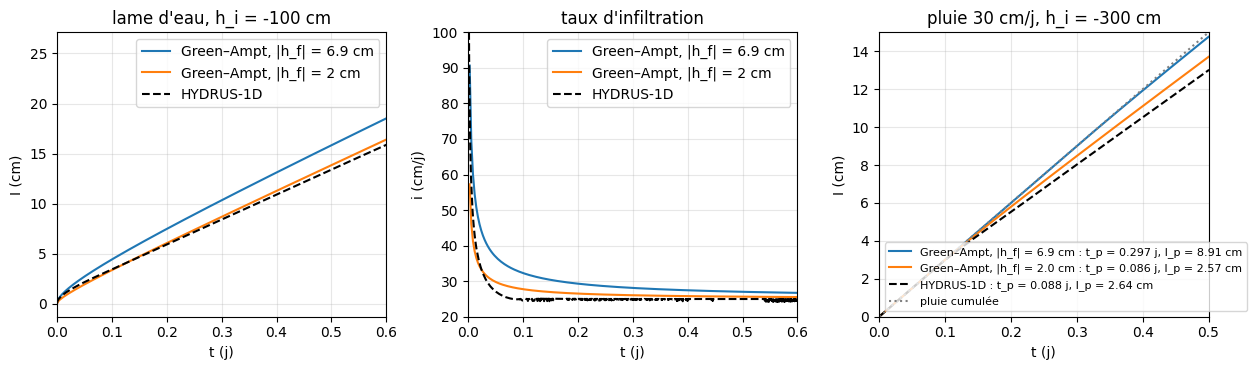

Green–Ampt avec |h_f| = int Kr dh = 6.92 cm : t_p = 0.297 j (7.1 h), I_p = 8.91 cm
HYDRUS-1D : t_p = 0.0880 j (2.1 h), I_p = 2.64 cm  ->  |h_f| effectif = 2.05 cm
Sorptivité équivalente S = sqrt(2 Ks |h_f| dtheta) : 9.48 cm/j^0.5 (h_f = int Kr dh) ; 5.16 cm/j^0.5 (h_f effectif)


In [2]:
def green_ampt_cumul(t, Ks, hf, dtheta, h0=0.0):
    """I(t) (cm) sous lame d'eau h0 : résolution implicite de I - B ln(1 + I/B) = Ks t."""
    B = (hf + h0) * dtheta
    t = np.atleast_1d(np.asarray(t, float))
    return np.array([0.0 if tt <= 0 else optimize.brentq(lambda I: I - B * np.log(1 + I / B) - Ks * tt, 1e-9, Ks * tt + 50 * B + 1)
                     for tt in t])

def green_ampt_taux(I, Ks, hf, dtheta, h0=0.0):
    """Capacité d'infiltration i(I) = Ks (1 + B/I)."""
    return Ks * (1 + (hf + h0) * dtheta / np.asarray(I, float))

def temps_submersion(i, Ks, hf, dtheta):
    """Mein & Larson : (t_p, I_p) sous pluie constante i ; inf si i <= Ks."""
    if i <= Ks: return np.inf, np.inf
    Ip = Ks * hf * dtheta / (i - Ks)
    return Ip / i, Ip

def green_ampt_pluie(t, i, Ks, hf, dtheta):
    """I(t) sous pluie constante i > Ks : flux imposé jusqu'à t_p, puis Green–Ampt décalé."""
    B = hf * dtheta
    tp, Ip = temps_submersion(i, Ks, hf, dtheta)
    t = np.atleast_1d(np.asarray(t, float)); I = np.empty_like(t)
    for k, tt in enumerate(t):
        if tt <= tp:
            I[k] = i * tt
        else:
            f = lambda I_: I_ - Ip - B * np.log((B + I_) / (B + Ip)) - Ks * (tt - tp)
            I[k] = optimize.brentq(f, Ip, Ip + i * (tt - tp) + 1e-9)
    return I

p = SOLS["loam"]; Ks = p[4]
hf = h_front(p); dth300 = p[1] - float(vg_theta(-300, p)); dth100 = p[1] - float(vg_theta(-100, p))
print(f"loam : |h_f| = {hf:.2f} cm ; dtheta(h_i = -300) = {dth300:.3f} ; dtheta(h_i = -100) = {dth100:.3f}")

# (a) lame d'eau nulle, h_i = -100 : comparaison avec J06_infiltration_submergee_loam
tl6 = read_tlevel(f"{HYD}/J06_infiltration_submergee_loam")
t = np.linspace(0, 0.6, 200)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for hff, lab in [(hf, f"Green–Ampt, |h_f| = {hf:.1f} cm"), (2.0, "Green–Ampt, |h_f| = 2 cm")]:
    I = green_ampt_cumul(t, Ks, hff, dth100)
    ax[0].plot(t, I, label=lab); ax[1].plot(t[1:], green_ampt_taux(I[1:], Ks, hff, dth100), label=lab)
ax[0].plot(tl6.index, tl6["sum(Infil)"], "k--", label="HYDRUS-1D"); ax[1].plot(tl6.index, -tl6["vTop"], "k--", label="HYDRUS-1D")
ax[0].set(xlabel="t (j)", ylabel="I (cm)", xlim=(0, 0.6), title="lame d'eau, h_i = -100 cm"); ax[0].legend()
ax[1].set(xlabel="t (j)", ylabel="i (cm/j)", xlim=(0, 0.6), ylim=(20, 100), title="taux d'infiltration"); ax[1].legend()
# (b) pluie de 30 cm/j, h_i = -300 : comparaison avec J06_pluie_flux_impose_loam
tl6p = read_tlevel(f"{HYD}/J06_pluie_flux_impose_loam")
tp_hyd = tl6p.index[np.argmax(tl6p["hTop"].to_numpy() >= -1e-6)]; Ip_hyd = tl6p["sum(Infil)"].loc[tp_hyd]
tt = np.linspace(0, 0.5, 300)
for hff in [hf, 2.0]:
    tp, Ip = temps_submersion(30.0, Ks, hff, dth300)
    ax[2].plot(tt, green_ampt_pluie(tt, 30.0, Ks, hff, dth300), label=f"Green–Ampt, |h_f| = {hff:.1f} cm : t_p = {tp:.3f} j, I_p = {Ip:.2f} cm")
ax[2].plot(tl6p.index, tl6p["sum(Infil)"], "k--", label=f"HYDRUS-1D : t_p = {tp_hyd:.3f} j, I_p = {Ip_hyd:.2f} cm")
ax[2].plot(tt, 30 * tt, ":", color="gray", label="pluie cumulée")
ax[2].set(xlabel="t (j)", ylabel="I (cm)", xlim=(0, 0.5), ylim=(0, 15), title="pluie 30 cm/j, h_i = -300 cm"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# 4. h_f effectif reproduisant t_p de HYDRUS
hf_eff = optimize.brentq(lambda hff: temps_submersion(30.0, Ks, hff, dth300)[0] - tp_hyd, 0.1, 50)
tp_ga, Ip_ga = temps_submersion(30.0, Ks, hf, dth300)
print(f"Green–Ampt avec |h_f| = int Kr dh = {hf:.2f} cm : t_p = {tp_ga:.3f} j ({tp_ga * 24:.1f} h), I_p = {Ip_ga:.2f} cm")
print(f"HYDRUS-1D : t_p = {tp_hyd:.4f} j ({tp_hyd * 24:.1f} h), I_p = {Ip_hyd:.2f} cm  ->  |h_f| effectif = {hf_eff:.2f} cm")
print(f"Sorptivité équivalente S = sqrt(2 Ks |h_f| dtheta) : {np.sqrt(2 * Ks * hf * dth300):.2f} cm/j^0.5 (h_f = int Kr dh) ; "
      f"{np.sqrt(2 * Ks * hf_eff * dth300):.2f} cm/j^0.5 (h_f effectif)")

**Commentaire (instructeur).** Sous lame d'eau, Green–Ampt avec $|h_f| = \int K_r\,dh = 6{,}9$ cm surestime le cumul de 15 % par rapport à Richards ; sous pluie
de 30 cm/j (seulement 1,2 $K_s$), il retarde la submersion d'un facteur 3 (0,30 j contre 0,088 j). Le $|h_f|$ effectif est de 2 cm :
le front du loam de van Genuchten ($n = 1{,}56$) est diffus et la capacité d'infiltration retombe vers $K_s$ bien plus vite que
ne le prévoit le piston. Green–Ampt est un modèle de sol grossier ; pour les sols fins, $h_f$ doit être calé, d'autant plus que
$i_r/K_s$ est proche de 1 ($t_p \propto 1/(i_r - K_s)$).

## Exercice 2 — Essai au double anneau : Philip et Horton  *(≈ 15 min)*

`data/J07_double_anneau.csv` : infiltration cumulée $I$ (cm) mesurée pendant 3 h sur deux sites (A : loam ; B : loam sableux structuré).

1. Ajuster par `optimize.curve_fit` le modèle de Philip $I = S\sqrt{t} + At$ et celui de Horton
   $I = i_f t + (i_0 - i_f)(1 - e^{-kt})/k$ (temps en h) ; donner les paramètres et la RMSE de chaque modèle et de chaque site.
2. Tracer $I(t)$ mesuré et ajusté, puis $i(t)$ des deux modèles jusqu'à 6 h (extrapolation) ; comparer $A$ et $i_f$.
3. Estimer $K_s$ ($\approx A/0{,}4$ et $\approx i_f$), le temps gravitaire $t_{grav} = (S/K_s)^2$ et la longueur capillaire
   $\lambda_c = b S^2/(\Delta\theta K_s)$ (White & Sully, $b = 0{,}55$, $\Delta\theta = 0{,}25$) ; comparer aux valeurs de Carsel & Parrish.

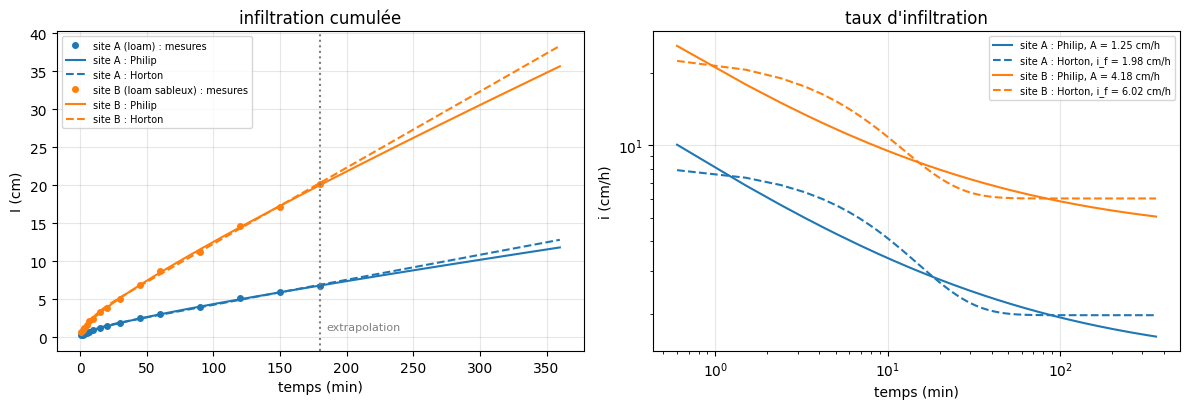

site,A,B
texture,loam,loam sableux
S_cm_h05,1.759532,4.325
A_cm_h,1.251986,4.180125
RMSE_Philip,0.043034,0.148682
i0_cm_h,8.278708,23.687342
i_f_cm_h,1.975969,6.017813
k_1_h,6.482993,7.811648
RMSE_Horton,0.088087,0.214109
Ks_A_cm_h,3.129966,10.450313
Ks_if_cm_h,1.975969,6.017813


In [3]:
da = pd.read_csv("data/J07_double_anneau.csv")
philip = lambda t, S, A: S * np.sqrt(t) + A * t
horton = lambda t, i0, i_f, k: i_f * t + (i0 - i_f) * (1 - np.exp(-k * t)) / k
rmse = lambda y, yh: np.sqrt(np.mean((y - yh)**2))
tt = np.linspace(0.01, 6, 400)
res = []
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for site, g in da.groupby("site"):
    t = g["t_min"].to_numpy() / 60.0; I = g["I_cm"].to_numpy(); tex = g["texture"].iloc[0]
    pP, _ = optimize.curve_fit(philip, t, I, p0=[1, 1])
    pH, _ = optimize.curve_fit(horton, t, I, p0=[5, 1, 2], bounds=(0, [50, 20, 50]))
    S, A = pP; i0, i_f, k = pH
    Ks_A, Ks_H = A / 0.4, i_f
    res.append(dict(site=site, texture=tex, S_cm_h05=S, A_cm_h=A, RMSE_Philip=rmse(I, philip(t, *pP)),
                    i0_cm_h=i0, i_f_cm_h=i_f, k_1_h=k, RMSE_Horton=rmse(I, horton(t, *pH)),
                    Ks_A_cm_h=Ks_A, Ks_if_cm_h=Ks_H, t_grav_h=(S / Ks_A)**2, lambda_c_cm=0.55 * S**2 / (0.25 * Ks_A),
                    Ks_CarselParrish_cm_h=SOLS[tex][4] / 24))
    l, = ax[0].plot(t * 60, I, "o", ms=4, label=f"site {site} ({tex}) : mesures")
    ax[0].plot(tt * 60, philip(tt, *pP), color=l.get_color(), label=f"site {site} : Philip")
    ax[0].plot(tt * 60, horton(tt, *pH), "--", color=l.get_color(), label=f"site {site} : Horton")
    ax[1].loglog(tt * 60, S / (2 * np.sqrt(tt)) + A, color=l.get_color(), label=f"site {site} : Philip, A = {A:.2f} cm/h")
    ax[1].loglog(tt * 60, i_f + (i0 - i_f) * np.exp(-k * tt), "--", color=l.get_color(), label=f"site {site} : Horton, i_f = {i_f:.2f} cm/h")
ax[0].axvline(180, color="gray", ls=":"); ax[0].text(185, 1, "extrapolation", color="gray", fontsize=8)
ax[0].set(xlabel="temps (min)", ylabel="I (cm)", title="infiltration cumulée"); ax[0].legend(fontsize=7)
ax[1].set(xlabel="temps (min)", ylabel="i (cm/h)", title="taux d'infiltration"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
display(pd.DataFrame(res).set_index("site").T.round(3))

**Commentaire (instructeur).** Les deux modèles reproduisent les mesures à 0,05–0,2 cm près (bruit de 2 %) mais divergent en extrapolation : après 3 h, Philip
tend vers $A$ et Horton vers $i_f$, qui diffèrent de 40 à 60 %. Le site B (loam sableux structuré) a une sorptivité 2,5 fois
plus grande et un $K_s$ apparent 3 fois plus grand que le site A : en surface, les macropores dominent, et $K_s$ estimé au double
anneau dépasse la valeur de catalogue de la matrice. $t_{grav}$ (0,3 h sur A, 0,2 h sur B) rappelle que la série de Philip
tronquée ne décrit que le début de l'essai.

## Exercice 3 — Sols stratifiés dans HYDRUS-1D : loam sur sable, sable sur loam  *(≈ 15 min)*

Projets `J07_stratifie_loam_sur_sable` et `J07_stratifie_sable_sur_loam` : deux couches (0–30 cm / 30–100 cm), $h_i = -200$ cm,
lame d'eau nulle en surface, drainage libre, 1 j, nœuds d'observation à 10, 25, 35 et 60 cm.

1. Tracer les profils $\theta(z)$ et $h(z)$ (`read_nod_inf`) à 0,1 ; 0,25 ; 0,5 ; 1 j pour les deux projets.
2. Tracer `vTop`$(t)$ et `sum(Infil)`$(t)$ (`read_tlevel`) ; donner $I(1\,\mathrm{j})$ (attendu : 26,1 cm contre 45,1 cm) et le flux
   final au bas.
3. Position du front en fonction du temps (premier nœud, en partant de la surface, où $\theta < \theta_i + 0{,}02$) pour chaque temps
   d'impression ; identifier l'arrêt à l'interface.
4. `read_obs_node` : $h(t)$ à 25 et 35 cm ; vérifier, pour loam sur sable, que le sable ne transmet le flux qu'une fois $h$ à l'interface
   remonté à $\approx -9$ cm (résoudre $K_{sable}(h) = K_{s,loam}$ avec `brentq`) et que $\theta_{sable}$ vaut alors $\approx 0{,}235$.

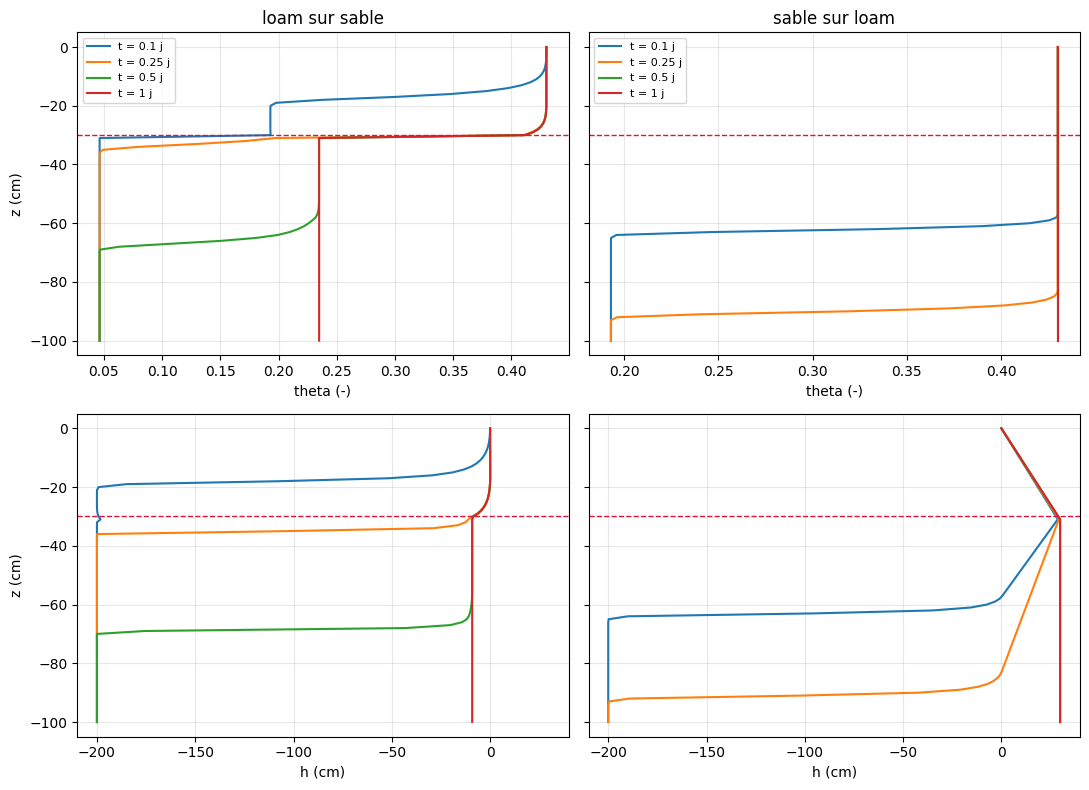

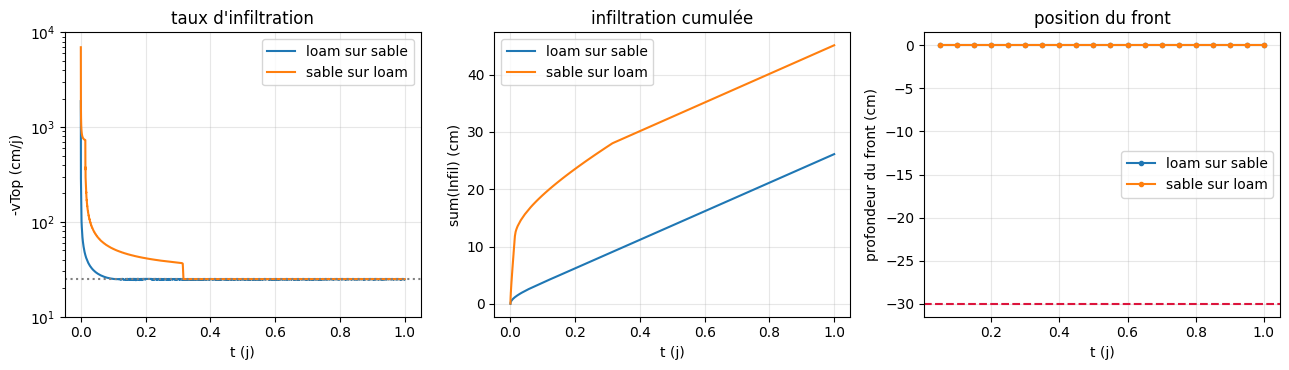

,I_1j_cm,vTop_1j,vBot_1j,Volume_0,Volume_1j
profil,,,,,
loam sur sable,26.126,-24.728,-24.911,9.246,29.392
sable sur loam,45.116,-24.958,-24.960,15.090,43.000


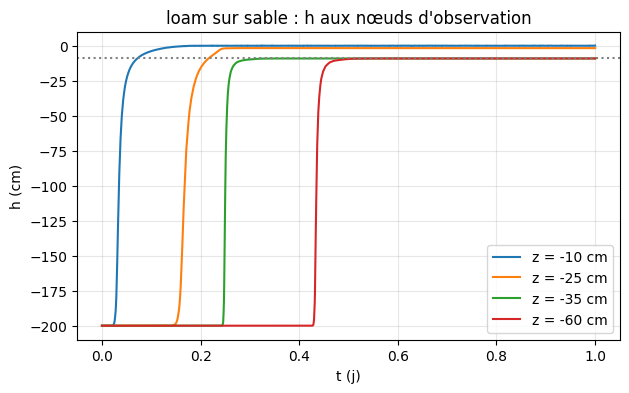

K_sable(h) = K_s,loam = 24.96 cm/j pour h = -8.97 cm ; theta_sable(h*) = 0.237
h à 35 cm (sable) à 0,5 et 1 j : [-9.11, -9.1] ; theta à 35 cm à 1 j : 0.235


In [4]:
projets = {"loam sur sable": f"{HYD}/J07_stratifie_loam_sur_sable", "sable sur loam": f"{HYD}/J07_stratifie_sable_sur_loam"}
temps = [0.1, 0.25, 0.5, 1.0]
fig, ax = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
fronts = {}
for k, (nom, P) in enumerate(projets.items()):
    nod = read_nod_inf(P)
    th_i = nod[0.0]["Moisture"].to_numpy(); z = nod[0.0]["Depth"].to_numpy()
    for t in temps:
        d = nod[t]
        ax[0, k].plot(d["Moisture"], d["Depth"], label=f"t = {t:g} j"); ax[1, k].plot(d["Head"], d["Depth"])
    for a in ax[:, k]: a.axhline(-30, color="crimson", ls="--", lw=1)
    ax[0, k].set(xlabel="theta (-)", title=nom); ax[1, k].set(xlabel="h (cm)", xlim=(-210, 40))
    ax[0, k].legend(fontsize=8)
    # position du front à chaque temps d'impression
    fronts[nom] = {t: z[np.argmax(nod[t]["Moisture"].to_numpy() < th_i + 0.02)] for t in sorted(nod) if t > 0}
ax[0, 0].set_ylabel("z (cm)"); ax[1, 0].set_ylabel("z (cm)")
plt.tight_layout(); plt.show()

# 2. flux et cumuls
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
bil = []
for nom, P in projets.items():
    tl = read_tlevel(P)
    ax[0].semilogy(tl.index, -tl["vTop"], label=nom); ax[1].plot(tl.index, tl["sum(Infil)"], label=nom)
    bil.append(dict(profil=nom, I_1j_cm=tl["sum(Infil)"].iloc[-1], vTop_1j=tl["vTop"].iloc[-1], vBot_1j=tl["vBot"].iloc[-1],
                    Volume_0=tl["Volume"].iloc[0], Volume_1j=tl["Volume"].iloc[-1]))
    fr = fronts[nom]; ax[2].plot(list(fr.keys()), list(fr.values()), "o-", ms=3, label=nom)
ax[0].axhline(SOLS["loam"][4], color="gray", ls=":"); ax[0].set(xlabel="t (j)", ylabel="-vTop (cm/j)", title="taux d'infiltration", ylim=(10, 1e4)); ax[0].legend()
ax[1].set(xlabel="t (j)", ylabel="sum(Infil) (cm)", title="infiltration cumulée"); ax[1].legend()
ax[2].axhline(-30, color="crimson", ls="--"); ax[2].set(xlabel="t (j)", ylabel="profondeur du front (cm)", title="position du front"); ax[2].legend()
plt.tight_layout(); plt.show()
display(pd.DataFrame(bil).set_index("profil").round(3))

# 4. h à l'interface (loam sur sable) et condition de transmission du sable
ob = read_obs_node(projets["loam sur sable"])
h_star = optimize.brentq(lambda h: vg_K(h, SOLS["sable"]) - SOLS["loam"][4], -100, -0.1)
fig, ax = plt.subplots()
for nd, zz in zip([11, 26, 36, 61], [10, 25, 35, 60]):
    ax.plot(ob.index, ob[(nd, "h")], label=f"z = -{zz} cm")
ax.axhline(h_star, color="gray", ls=":"); ax.set(xlabel="t (j)", ylabel="h (cm)", ylim=(-210, 10), title="loam sur sable : h aux nœuds d'observation"); ax.legend()
plt.show()
nod = read_nod_inf(projets["loam sur sable"])
print(f"K_sable(h) = K_s,loam = {SOLS['loam'][4]} cm/j pour h = {h_star:.2f} cm ; theta_sable(h*) = {float(vg_theta(h_star, SOLS['sable'])):.3f}")
print("h à 35 cm (sable) à 0,5 et 1 j :", ob[(36, 'h')].iloc[[np.argmin(abs(ob.index - 0.5)), -1]].round(2).tolist(),
      "; theta à 35 cm à 1 j :", round(float(nod[1.0]['Moisture'].iloc[35]), 3))

**Commentaire (instructeur).** Loam sur sable : le front s'arrête à l'interface entre 0,15 et 0,25 j, le temps que $h$ y remonte de −200 à −9 cm ; à cette pression
$K_{sable} = K_{s,loam}$ et le sable évacue les 25 cm/j du loam à gradient unitaire avec $\theta = 0{,}235$ seulement : c'est la
barrière capillaire (le sable est « moins conducteur » que le loam tant qu'il est sec). Le cumul (26,1 cm) est celui du loam seul.
Sable sur loam : le sable se sature en 0,02 j (nappe perchée, $h > 0$ à l'interface), puis le loam contrôle le flux à $K_s$ ; le
cumul (45,1 cm) inclut le stockage de 11,5 cm dans le sable.

## Exercice 4 — Croûte de battance dans HYDRUS-1D  *(≈ 10 min)*

Projets `J07_croute_sans_croute` (loam, 101 nœuds) et `J07_croute_avec_croute` (croûte de 1 cm à $K_s = 0{,}5$ cm/j, 201 nœuds) :
pluie de 10 cm/j pendant 0,5 j, $h_i = -300$ cm, condition atmosphérique avec ruissellement.

1. Tracer `vTop`, `sum(Infil)`, `sum(RunOff)` et `hTop` pour les deux projets ; temps de submersion, infiltration et ruissellement
   totaux, coefficient de ruissellement.
2. Taux d'infiltration stationnaire sous lame d'eau nulle avec croûte ($K_s$ « effective » du système) ; le comparer à $K_s$ du loam.
3. Profils $h(z)$ sur 0–20 cm à 0,25 j (`read_nod_inf`) : pression $h_{sub}$ sous la croûte, gradient de charge à travers la croûte,
   résistance hydraulique $R_c = \Delta H / i$ ; vérifier que $K_{loam}(h_{sub}) < i$ (le sol sous la croûte n'est pas à gradient unitaire).

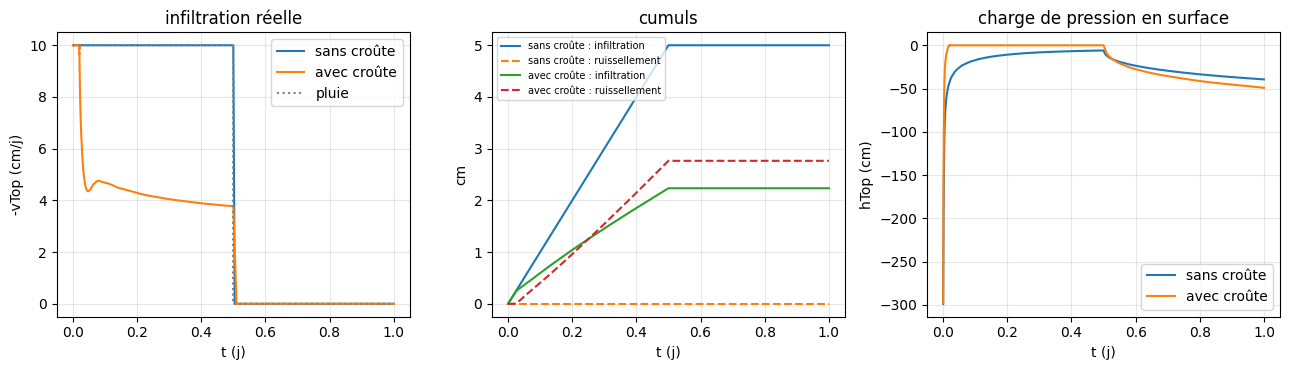

,t_submersion_j,infiltration_cm,ruissellement_cm,coef_ruissellement,i_stationnaire_cm_j
cas,,,,,
sans croûte,NaN,5.000,0.000,0.000,10.000
avec croûte,0.019,2.235,2.765,0.553,4.008


Ks effective du système avec croûte ≈ 4.01 cm/j, soit 0.16 Ks du loam


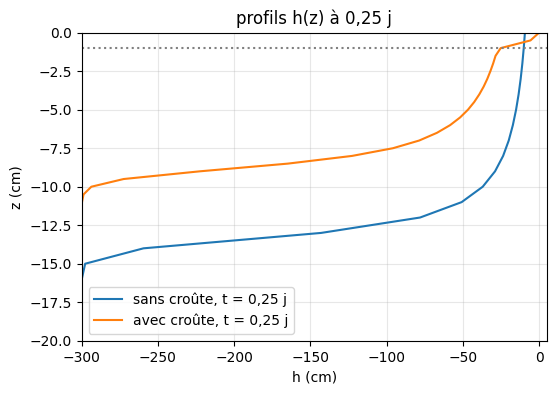

t = 0,25 j : h sous la croûte = -25.2 cm ; gradient de charge à travers la croûte = 26.2 ; i = 4.15 cm/j ; résistance R_c = dH/i = 6.30 j ; K_c moyen = 1 cm / R_c = 0.159 cm/j
K_loam(h_sub) = 1.31 cm/j < i : le loam sous la croûte est à gradient > 1 (front encore proche)


In [5]:
crout = {"sans croûte": f"{HYD}/J07_croute_sans_croute", "avec croûte": f"{HYD}/J07_croute_avec_croute"}
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
rows = []
for nom, P in crout.items():
    tl = read_tlevel(P)
    ax[0].plot(tl.index, -tl["vTop"], label=nom); ax[1].plot(tl.index, tl["sum(Infil)"], label=f"{nom} : infiltration")
    ax[1].plot(tl.index, tl["sum(RunOff)"], "--", label=f"{nom} : ruissellement"); ax[2].plot(tl.index, tl["hTop"], label=nom)
    sub = tl[(tl.index > 0.2) & (tl.index < 0.5)]
    tp = tl.index[np.argmax(tl["hTop"].to_numpy() >= -1e-6)] if (tl["hTop"] >= -1e-6).any() else np.nan
    rows.append(dict(cas=nom, t_submersion_j=tp, infiltration_cm=tl["sum(Infil)"].iloc[-1], ruissellement_cm=tl["sum(RunOff)"].iloc[-1],
                     coef_ruissellement=tl["sum(RunOff)"].iloc[-1] / 5.0, i_stationnaire_cm_j=-sub["vTop"].mean()))
ax[0].plot([0, 0.5, 0.5, 1], [10, 10, 0, 0], ":", color="gray", label="pluie"); ax[0].set(xlabel="t (j)", ylabel="-vTop (cm/j)", title="infiltration réelle"); ax[0].legend()
ax[1].set(xlabel="t (j)", ylabel="cm", title="cumuls"); ax[1].legend(fontsize=7)
ax[2].set(xlabel="t (j)", ylabel="hTop (cm)", title="charge de pression en surface"); ax[2].legend()
plt.tight_layout(); plt.show()
tab = pd.DataFrame(rows).set_index("cas"); display(tab.round(3))
print(f"Ks effective du système avec croûte ≈ {tab.loc['avec croûte', 'i_stationnaire_cm_j']:.2f} cm/j, soit {tab.loc['avec croûte', 'i_stationnaire_cm_j'] / SOLS['loam'][4]:.2f} Ks du loam")

# 3. profils de pression près de la surface et résistance de la croûte
fig, ax = plt.subplots(figsize=(6, 4))
for nom, P in crout.items():
    nod = read_nod_inf(P); d = nod[0.25]
    ax.plot(d["Head"], d["Depth"], label=f"{nom}, t = 0,25 j")
ax.axhline(-1, color="gray", ls=":"); ax.set(xlabel="h (cm)", ylabel="z (cm)", ylim=(-20, 0), xlim=(-300, 5), title="profils h(z) à 0,25 j"); ax.legend()
plt.show()
d = read_nod_inf(crout["avec croûte"])[0.25]
h_sub = float(d["Head"].iloc[2])                        # nœud 3 : z = -1 cm (base de la croûte, dz = 0,5 cm)
i_025 = -float(read_tlevel(crout["avec croûte"])["vTop"].loc[lambda s: (s.index > 0.24) & (s.index < 0.26)].mean())
dH = (0 + 0) - (h_sub - 1.0)                            # H_surface - H_base = 0 - (h_sub + z_base)
print(f"t = 0,25 j : h sous la croûte = {h_sub:.1f} cm ; gradient de charge à travers la croûte = {dH / 1.0:.1f} ; "
      f"i = {i_025:.2f} cm/j ; résistance R_c = dH/i = {dH / i_025:.2f} j ; K_c moyen = 1 cm / R_c = {1 / (dH / i_025):.3f} cm/j")
print(f"K_loam(h_sub) = {float(vg_K(h_sub, SOLS['loam'])):.2f} cm/j < i : le loam sous la croûte est à gradient > 1 (front encore proche)")

**Commentaire (instructeur).** Sans croûte, 10 cm/j $< K_s$ : tout s'infiltre et la surface reste non saturée ($h \approx -6$ cm à 0,5 j). Avec une croûte de 1 cm
à $K_s/50$, la submersion survient après 28 min et le taux d'infiltration tombe à $\approx 4$ cm/j : 55 % de la pluie ruisselle.
La croûte n'est même pas saturée sur toute son épaisseur ($h$ passe de 0 à −25 cm en 1 cm, gradient 26) : sa conductivité moyenne
effective (0,15 cm/j) est inférieure à son $K_s$. Le loam sous-jacent reste à $h \approx -25$ cm, non saturé, avec un gradient encore
supérieur à 1 pendant la pluie ; il se redistribue ensuite lentement.

## Exercice 5 — Bonus — Green–Ampt à deux couches (sable sur loam)  *(≈ facultatif)*

Généraliser Green–Ampt à un profil à deux couches (Childs & Bybordi 1969) : quand le front est dans la couche 2 (profondeur $L_f > L_1$),
la conductivité effective en série est $K_{eff} = L_f/[L_1/K_1 + (L_f - L_1)/K_2]$ et $i = K_{eff}(h_0 + |h_{f,2}| + L_f)/L_f$,
avec $dL_f/dt = i/\Delta\theta_2$. Intégrer (`integrate.solve_ivp`) pour sable (30 cm) sur loam, $h_i = -200$ cm, lame nulle, et comparer
$I(t)$ et $i(t)$ à `J07_stratifie_sable_sur_loam` (45,1 cm à 1 j). Pourquoi le cas loam sur sable ne se traite-t-il pas ainsi ?

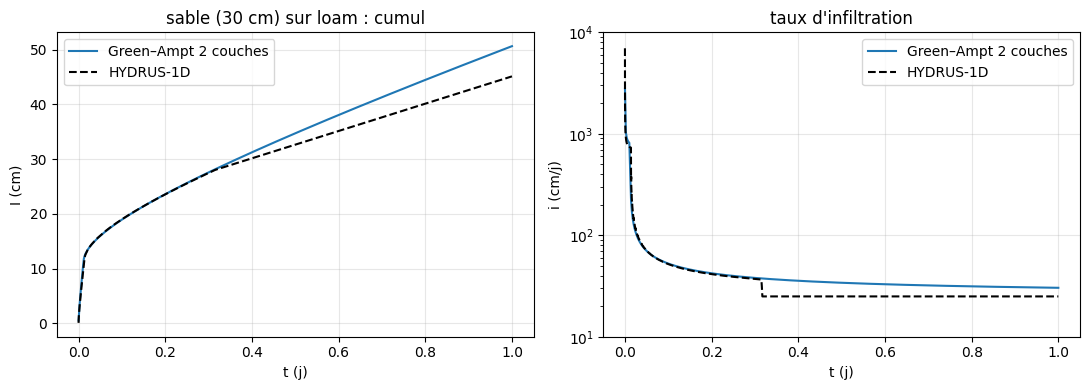

front à l'interface à t = 0.0121 j (Green–Ampt) ; I(1 j) = 50.6 cm (Green–Ampt) contre 45.1 cm (HYDRUS)


In [6]:
p1, p2 = SOLS["sable"], SOLS["loam"]; L1 = 30.0
dth1 = p1[1] - float(vg_theta(-200, p1)); dth2 = p2[1] - float(vg_theta(-200, p2))
hf1, hf2 = h_front(p1, -200), h_front(p2, -200)
K1, K2 = p1[4], p2[4]

def taux(L):
    """Capacité d'infiltration (cm/j) quand le front est à la profondeur L (cm)."""
    if L <= L1:
        return K1 * (hf1 + L) / L
    Keff = L / (L1 / K1 + (L - L1) / K2)
    return Keff * (hf2 + L) / L

def rhs(t, y):
    L = y[0]
    return [taux(L) / (dth1 if L <= L1 else dth2)]

sol = integrate.solve_ivp(rhs, [0, 1.0], [1e-3], max_step=1e-3, rtol=1e-8, dense_output=True)
t = np.linspace(1e-4, 1.0, 500); L = sol.sol(t)[0]
I = np.where(L <= L1, L * dth1, L1 * dth1 + (L - L1) * dth2)
i = np.array([taux(l) for l in L])
tl = read_tlevel(f"{HYD}/J07_stratifie_sable_sur_loam")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, I, label="Green–Ampt 2 couches"); ax[0].plot(tl.index, tl["sum(Infil)"], "k--", label="HYDRUS-1D")
ax[0].set(xlabel="t (j)", ylabel="I (cm)", title="sable (30 cm) sur loam : cumul"); ax[0].legend()
ax[1].semilogy(t, i, label="Green–Ampt 2 couches"); ax[1].semilogy(tl.index, -tl["vTop"], "k--", label="HYDRUS-1D")
ax[1].set(xlabel="t (j)", ylabel="i (cm/j)", ylim=(10, 1e4), title="taux d'infiltration"); ax[1].legend()
plt.tight_layout(); plt.show()
t_int = t[np.argmax(L > L1)]
print(f"front à l'interface à t = {t_int:.4f} j (Green–Ampt) ; I(1 j) = {I[-1]:.1f} cm (Green–Ampt) contre {tl['sum(Infil)'].iloc[-1]:.1f} cm (HYDRUS)")

**Commentaire (instructeur).** Pour le sable sur loam, le modèle piston à deux couches capture l'essentiel : le sable se remplit en un centième de jour puis le
loam limite le flux, qui tend vers $K_{s,loam}$ ; le cumul à 1 j est surestimé de 12 % (50,6 contre 45,1 cm), car $|h_f|$ du loam
($\int K_r\,dh$ = 7 cm) est trop grand pour ce sol à front diffus (voir exercice 1). Le cas loam sur sable ne se traite pas
ainsi : le sable n'est jamais saturé (il transmet le flux à $h \approx -9$ cm et $\theta = 0{,}235$), ce qui contredit l'hypothèse de
piston saturé ; il faut remplacer $h_f$ du sable par sa pression d'entrée d'eau et $\Delta\theta$ par $\theta(-9) - \theta_i$, ou
simplement utiliser Richards.

## Pour aller plus loin

* Avec le solveur `richards_1d` du Jour 6 (paramètres par nœud), reproduire `J07_stratifie_loam_sur_sable` et tester l'effet de $\Delta z$ à l'interface.
* Ajuster Green–Ampt ($K_s$, $h_f$) sur les courbes du double anneau et comparer $S = \sqrt{2 K_s |h_f| \Delta\theta}$ au $S$ de Philip.
* Calculer la lame ruisselée SCS-CN d'une pluie de 60 mm pour $CN$ = 60, 78, 90 et la comparer au ruissellement Green–Ampt (ex. 1) pour la même pluie en 1 h, 3 h et 12 h.